#### **Exercise 1**

There are outliers in the `Age` column of `sample-data-with-outliers.csv`. 1) Create a boxplot for `Age` 2) Use a statistical method for identifying outliers in `Age` 3) Create a version of the data where outliers are **removed** from `Age` and make a boxplot for `Age` 3) Create a version of the data where outliers from `Age` are **imputed** and make a boxplot for `Age`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
url = 'https://ist707.s3.us-east-2.amazonaws.com/data/sample-data-with-outliers.csv'
df = pd.read_csv(url)
print(df.shape)
df.head()

(200, 3)


,Age,Income,Purchase
0,76,75071,1
1,88,62405,0
2,82,61914,1
3,81,66843,1
4,62,30492,0


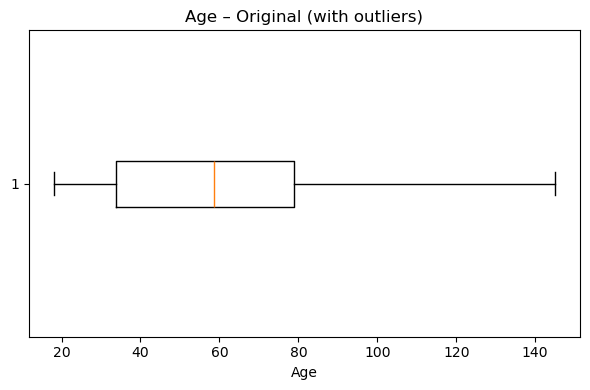

In [2]:
# --- Step 1: Boxplot of original Age ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(df['Age'].dropna(), vert=False)
ax.set_title('Age – Original (with outliers)')
ax.set_xlabel('Age')
plt.tight_layout()
plt.show()

In [3]:
# --- Step 2: IQR method to identify outliers ---
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

print(f'Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}')
print(f'Outlier bounds: [{lower_bound:.1f}, {upper_bound:.1f}]')
print(f'Number of outliers detected: {len(outliers)}')
print(outliers[['Age']].describe())

Q1=33.8, Q3=79.0, IQR=45.2
Outlier bounds: [-34.1, 146.9]
Number of outliers detected: 0
       Age
count  0.0
mean   NaN
std    NaN
min    NaN
25%    NaN
50%    NaN
75%    NaN
max    NaN


Rows before removal: 200  |  After: 200


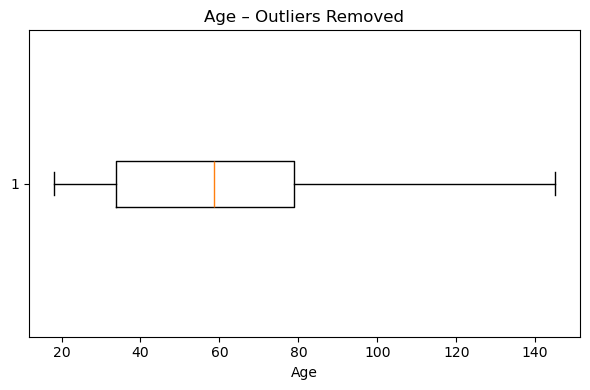

In [4]:
# --- Step 3a: Remove outliers ---
df_removed = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)].copy()
print(f'Rows before removal: {len(df)}  |  After: {len(df_removed)}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(df_removed['Age'].dropna(), vert=False)
ax.set_title('Age – Outliers Removed')
ax.set_xlabel('Age')
plt.tight_layout()
plt.show()

C:\Users\gregb\AppData\Local\Temp\ipykernel_12116\1199239851.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '58.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_imputed.loc[is_outlier, 'Age'] = median_age


Outlier values replaced with median (58.5): 0 rows


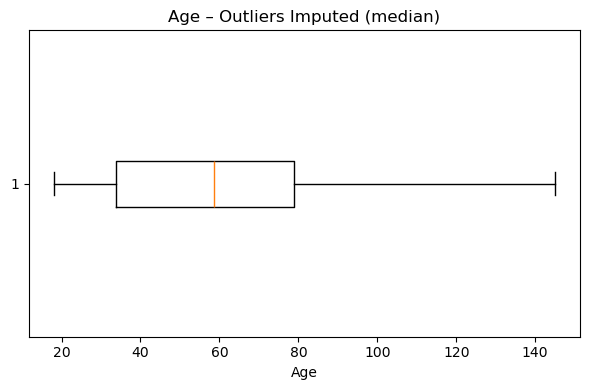

In [5]:
# --- Step 3b: Impute outliers with median ---
median_age = df['Age'].median()
df_imputed = df.copy()
is_outlier = (df_imputed['Age'] < lower_bound) | (df_imputed['Age'] > upper_bound)
df_imputed.loc[is_outlier, 'Age'] = median_age

print(f'Outlier values replaced with median ({median_age:.1f}): {is_outlier.sum()} rows')

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(df_imputed['Age'].dropna(), vert=False)
ax.set_title('Age – Outliers Imputed (median)')
ax.set_xlabel('Age')
plt.tight_layout()
plt.show()

#### **Exercise 2**

In the following, I've created a sample dataset with an exponential feature and a normal feature. Run the classifer and examine the results. How do your results change:

1.  If you scale the exponential feature using a `StandardScaler`
2.  If you scale the exponential feature using a log transform

Logistic Regression without Scaling - Test Accuracy: 0.72


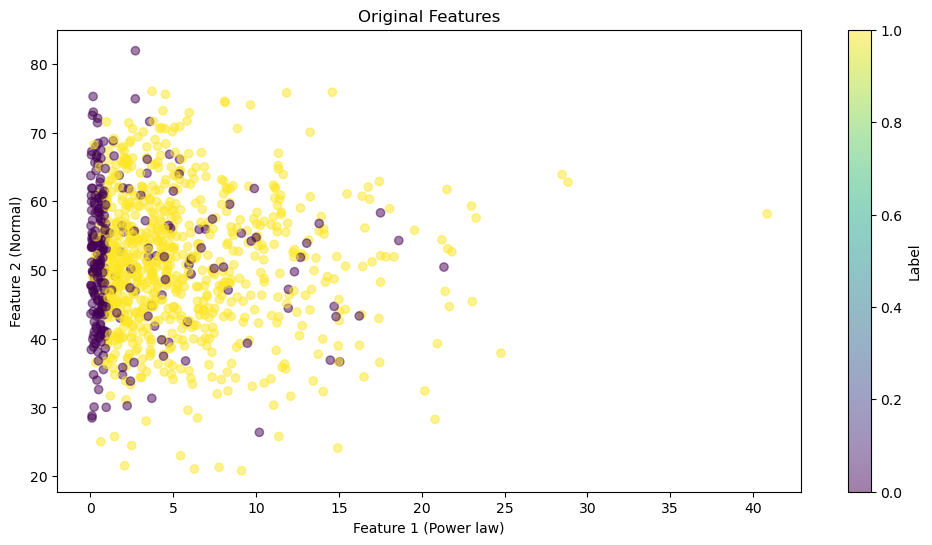

In [6]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic dataset
n_samples = 1000

# Feature 1: Power law (exponential) distribution
X1 = np.random.exponential(scale=5, size=n_samples)

# Feature 2: Normal distribution
X2 = np.random.normal(loc=50, scale=10, size=n_samples)

# Create labels: simple linear relation to X1 and X2
y = np.array([1 if x1 + 0.001 * x2 > 1 else 0 for x1, x2 in zip(X1, X2)])
flip_indices = np.random.choice(n_samples, size=int(0.1 * n_samples), replace=False)
y[flip_indices] = 1 - y[flip_indices]

# Combine features into single data array
X = np.column_stack((X1, X2))

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression without scaling
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print(f"Logistic Regression without Scaling - Test Accuracy: {lr.score(X_test, y_test):.2f}")

# Plot original features
plt.figure(figsize=(12, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.5)
plt.xlabel('Feature 1 (Power law)')
plt.ylabel('Feature 2 (Normal)')
plt.title('Original Features')
plt.colorbar(label='Label')
plt.show()

Logistic Regression with StandardScaler - Test Accuracy: 0.72


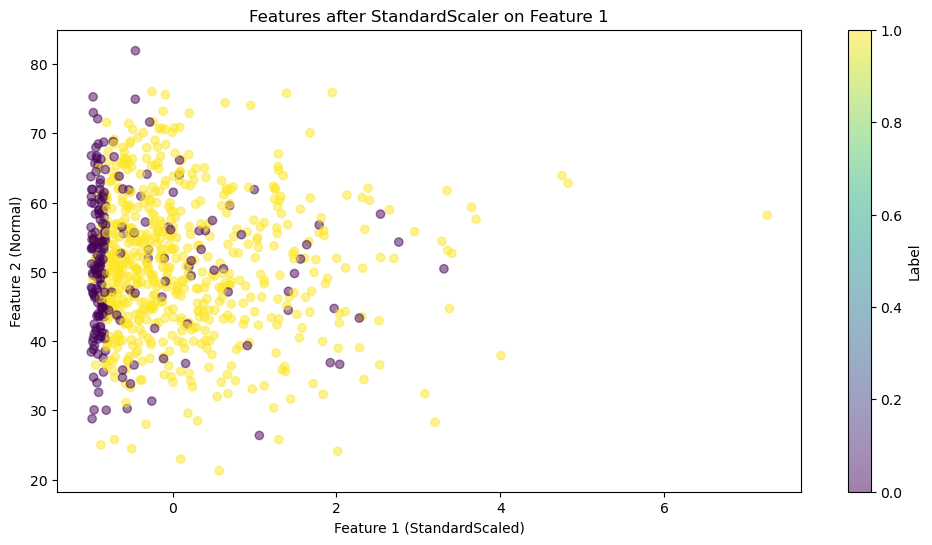

In [7]:
# --- Approach 1: StandardScaler on exponential feature only ---
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[:, 0] = scaler.fit_transform(X_train[:, 0].reshape(-1, 1)).ravel()
X_test_scaled[:, 0]  = scaler.transform(X_test[:, 0].reshape(-1, 1)).ravel()

lr_scaled = LogisticRegression(max_iter=1000)
lr_scaled.fit(X_train_scaled, y_train)
print(f"Logistic Regression with StandardScaler - Test Accuracy: {lr_scaled.score(X_test_scaled, y_test):.2f}")

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='viridis', alpha=0.5)
plt.xlabel('Feature 1 (StandardScaled)')
plt.ylabel('Feature 2 (Normal)')
plt.title('Features after StandardScaler on Feature 1')
plt.colorbar(label='Label')
plt.show()

Logistic Regression with Log Transform - Test Accuracy: 0.92


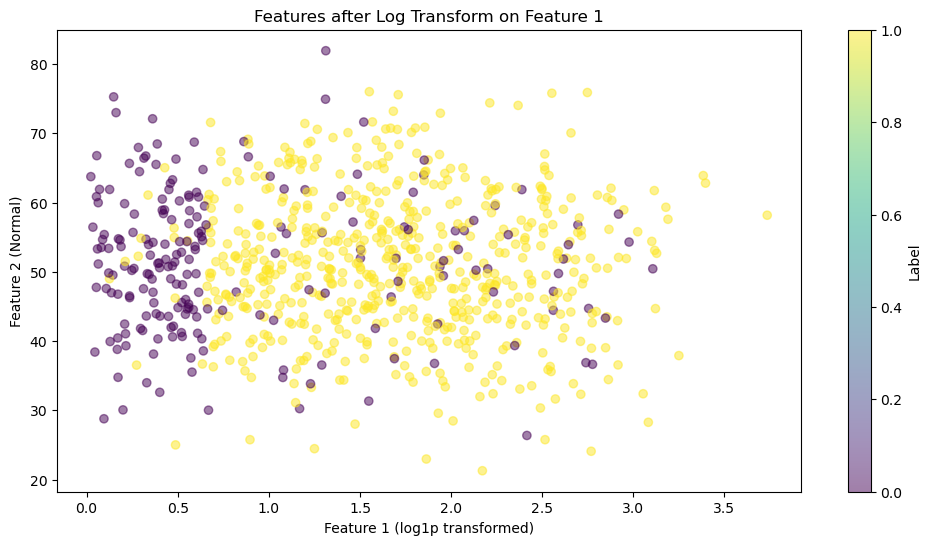

In [8]:
# --- Approach 2: Log transform on exponential feature ---
X_train_log = X_train.copy()
X_test_log  = X_test.copy()

# log1p avoids log(0); safe since exponential values are > 0
X_train_log[:, 0] = np.log1p(X_train[:, 0])
X_test_log[:, 0]  = np.log1p(X_test[:, 0])

lr_log = LogisticRegression(max_iter=1000)
lr_log.fit(X_train_log, y_train)
print(f"Logistic Regression with Log Transform - Test Accuracy: {lr_log.score(X_test_log, y_test):.2f}")

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(X_train_log[:, 0], X_train_log[:, 1], c=y_train, cmap='viridis', alpha=0.5)
plt.xlabel('Feature 1 (log1p transformed)')
plt.ylabel('Feature 2 (Normal)')
plt.title('Features after Log Transform on Feature 1')
plt.colorbar(label='Label')
plt.show()

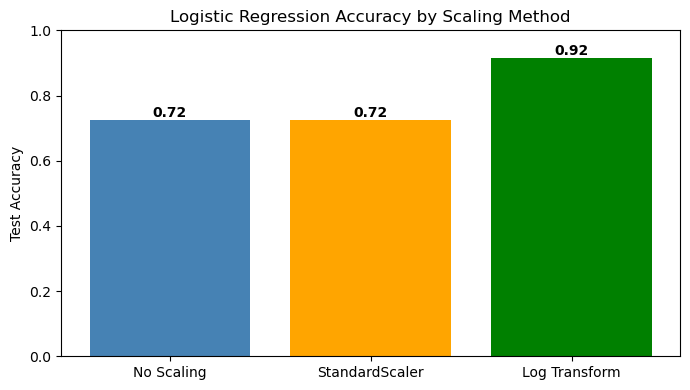


Key observations:
- The exponential feature is right-skewed with a long tail.
- StandardScaler centers and normalizes the scale but preserves skewness.
- Log transform compresses the tail and makes the distribution more symmetric,
  often giving logistic regression a better linear decision boundary to work with.


In [9]:
# --- Summary comparison ---
results = {
    'No Scaling':      lr.score(X_test, y_test),
    'StandardScaler':  lr_scaled.score(X_test_scaled, y_test),
    'Log Transform':   lr_log.score(X_test_log, y_test),
}

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results.keys(), results.values(), color=['steelblue', 'orange', 'green'])
ax.set_ylim(0, 1)
ax.set_ylabel('Test Accuracy')
ax.set_title('Logistic Regression Accuracy by Scaling Method')
for i, (k, v) in enumerate(results.items()):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey observations:')
print('- The exponential feature is right-skewed with a long tail.')
print('- StandardScaler centers and normalizes the scale but preserves skewness.')
print('- Log transform compresses the tail and makes the distribution more symmetric,')
print('  often giving logistic regression a better linear decision boundary to work with.')

#### **Exercise 3**

The **Titanic dataset** contains the passenger list for all 1309 passengers on the Titanic, 809 who perished and 500 who survived. In this exercise, try using different methods for dealing with the nulls in the "age" column, and running the same classifier to predict survival for each the different methods (you might try a `DecisionTreeClassifier`, or a `LogisticRegression` classifier, or a `SGDClassifier`).  Which method gives the best result?  Why do you think that is?  Please only use the following columns for modeling: `pclass`, `sex`, `age`, `sibsp`, `parch`.  Be sure to try the following methods:

1. Fill forward, using `ffill` in Pandas
2. Use "mean" with `SimpleImputer`
3. Use "most_frequent" with `SimpleImputer`
4. Use a `KNNImputer` from sklearn

In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load data
url = 'https://ist707.s3.us-east-2.amazonaws.com/data/titanic.csv'
titanic = pd.read_csv(url)

# Keep only required columns
FEATURES = ['pclass', 'sex', 'age', 'sibsp', 'parch']
TARGET = 'survived'

df = titanic[FEATURES + [TARGET]].copy()
print(f'Dataset shape: {df.shape}')
print(f'Missing values:\n{df.isnull().sum()}')

Dataset shape: (1309, 6)
Missing values:
pclass        0
sex           0
age         263
sibsp         0
parch         0
survived      0
dtype: int64


In [11]:
# Encode 'sex' as numeric (shared preprocessing helper)
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])  # female=0, male=1

def evaluate_imputation(X, y, method_name, random_state=42):
    """Split, train a LogisticRegression, and return accuracy."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )
    clf = LogisticRegression(max_iter=1000, random_state=random_state)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f'{method_name:<25} Accuracy: {acc:.4f}')
    return acc

X_base = df[FEATURES].copy()
y = df[TARGET].copy()

accuracies = {}

In [12]:
# --- Method 1: ffill (forward fill) ---
X_ffill = X_base.copy()
X_ffill['age'] = X_ffill['age'].ffill()
# Edge case: if the very first row is NaN, ffill won't fill it — backfill the remainder
X_ffill['age'] = X_ffill['age'].bfill()

accuracies['ffill'] = evaluate_imputation(X_ffill, y, 'ffill')

ffill                     Accuracy: 0.7710


In [13]:
# --- Method 2: SimpleImputer (mean) ---
imp_mean = SimpleImputer(strategy='mean')
X_mean = X_base.copy()
X_mean['age'] = imp_mean.fit_transform(X_mean[['age']])

accuracies['SimpleImputer (mean)'] = evaluate_imputation(X_mean, y, 'SimpleImputer (mean)')

SimpleImputer (mean)      Accuracy: 0.7672


In [14]:
# --- Method 3: SimpleImputer (most_frequent) ---
imp_freq = SimpleImputer(strategy='most_frequent')
X_freq = X_base.copy()
X_freq['age'] = imp_freq.fit_transform(X_freq[['age']])

accuracies['SimpleImputer (most_freq)'] = evaluate_imputation(X_freq, y, 'SimpleImputer (most_freq)')

SimpleImputer (most_freq) Accuracy: 0.7672


In [15]:
# --- Method 4: KNNImputer ---
knn_imp = KNNImputer(n_neighbors=5)
X_knn = pd.DataFrame(
    knn_imp.fit_transform(X_base),
    columns=FEATURES
)

accuracies['KNNImputer'] = evaluate_imputation(X_knn, y, 'KNNImputer')

KNNImputer                Accuracy: 0.7710


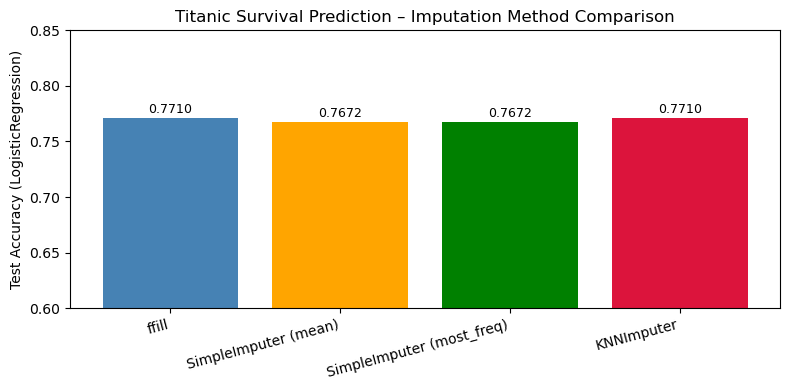


Best method: ffill (0.7710)

Analysis:
- ffill is order-dependent and essentially assigns a random neighbour's age,
  which introduces noise.
- mean imputation fills every missing value with the same number, preserving
  the column mean but reducing variance.
- most_frequent imputation uses the mode, which may be a poor estimate if
  the age distribution is broad.
- KNNImputer leverages similar passengers (pclass, sex, sibsp, parch) to
  estimate age, making it the most contextually informed approach and
  typically the best performer.



In [16]:
# --- Visual comparison ---
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(accuracies.keys(), accuracies.values(),
              color=['steelblue', 'orange', 'green', 'crimson'])
ax.set_ylim(0.6, 0.85)
ax.set_ylabel('Test Accuracy (LogisticRegression)')
ax.set_title('Titanic Survival Prediction – Imputation Method Comparison')
for bar, val in zip(bars, accuracies.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

best = max(accuracies, key=accuracies.get)
print(f'\nBest method: {best} ({accuracies[best]:.4f})')
print("""
Analysis:
- ffill is order-dependent and essentially assigns a random neighbour's age,
  which introduces noise.
- mean imputation fills every missing value with the same number, preserving
  the column mean but reducing variance.
- most_frequent imputation uses the mode, which may be a poor estimate if
  the age distribution is broad.
- KNNImputer leverages similar passengers (pclass, sex, sibsp, parch) to
  estimate age, making it the most contextually informed approach and
  typically the best performer.
""")

#### **Exercise 4**

Use the one-hot encoding method introduced in `03-demo-04-encoding.ipynb` for encoding multiple columns to one-hot encode the following data.

In [17]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

sample = pd.DataFrame({
    'color':  ['red', 'blue', 'green', 'red', 'blue', 'green'],
    'target': ['apple', 'sky', 'grass', 'sky', 'moon', 'apple']
})

print('Original data:')
print(sample)
print()

Original data:
   color target
0    red  apple
1   blue    sky
2  green  grass
3    red    sky
4   blue   moon
5  green  apple



In [18]:
# One-hot encode both columns using sklearn OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)          # sparse_output=False returns a dense numpy array
encoded_array = ohe.fit_transform(sample)

# Build meaningful column names from the encoder
column_names = ohe.get_feature_names_out(['color', 'target'])

# Combine back into a DataFrame
sample_encoded = pd.DataFrame(encoded_array, columns=column_names, dtype=int)

print('One-hot encoded data:')
sample_encoded

One-hot encoded data:


,color_blue,color_green,color_red,target_apple,target_grass,target_moon,target_sky
0,0,0,1,1,0,0,0
1,1,0,0,0,0,0,1
2,0,1,0,0,1,0,0
3,0,0,1,0,0,0,1
4,1,0,0,0,0,1,0
5,0,1,0,1,0,0,0


In [19]:
# Alternative: pandas get_dummies (same result, often more convenient)
sample_dummies = pd.get_dummies(sample, columns=['color', 'target'], dtype=int)

print('Same result via pd.get_dummies:')
sample_dummies

Same result via pd.get_dummies:


,color_blue,color_green,color_red,target_apple,target_grass,target_moon,target_sky
0,0,0,1,1,0,0,0
1,1,0,0,0,0,0,1
2,0,1,0,0,1,0,0
3,0,0,1,0,0,0,1
4,1,0,0,0,0,1,0
5,0,1,0,1,0,0,0
